# Отбор признаков (Feature Selection)

## 1. Генерация данных

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif,
    SelectFromModel, SequentialFeatureSelector,
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

x_data_generated, y_data_generated = make_classification(scale=1)

X = pd.DataFrame(
    x_data_generated,
    columns=[f'f{i}' for i in range(x_data_generated.shape[1])]
)
y = y_data_generated

print('Размер матрицы признаков:', X.shape)
print('Баланс классов:', np.bincount(y))

Размер матрицы признаков: (100, 20)
Баланс классов: [50 50]


In [2]:
X.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19
0,-2.025143,0.029102,-0.474945,-0.114736,0.504987,0.088962,0.404982,-0.653329,0.186454,-0.661786,-0.071335,2.143944,1.765454,0.852433,0.633919,0.087142,-0.792521,-0.334501,0.865755,-1.200296
1,1.613711,0.659924,-0.150056,-1.227608,0.597400,0.865620,0.015579,0.125576,0.453534,-0.244157,-1.158068,0.321357,-0.173072,0.964087,0.421921,0.963360,1.189470,1.375707,0.701173,-0.297564
2,0.166452,0.950573,1.420504,-0.530997,-0.623141,-2.255540,0.471416,-0.570746,0.492451,0.289169,-0.270624,-1.122722,-0.832356,2.455300,0.382410,-1.692005,-0.637740,1.189017,-0.555477,-0.637387
3,0.698223,-0.320670,1.735964,-0.535235,1.317394,-1.146581,-0.483886,0.197911,0.393485,0.895193,0.852392,0.059630,-0.651418,0.635172,-0.646937,-1.106450,1.049553,-0.689188,0.197600,2.075261
4,0.179894,-0.222100,0.105376,0.940771,-0.982487,1.560103,0.319782,-1.334025,1.392002,0.918317,-0.348985,-0.988591,-0.601368,-1.570501,-1.103589,1.303736,-0.989628,-0.968344,-0.224633,0.550052


## 2. Базовая модель на всех признаках

In [3]:
results = []

def evaluate(X_subset, name):
    """Средняя accuracy логистической регрессии по кросс-валидации."""
    acc = cross_val_score(
        LogisticRegression(max_iter=1000),
        X_subset, y, scoring='accuracy'
    ).mean()
    results.append({
        'способ выбора признаков': name,
        'количество признаков': X_subset.shape[1],
        'средняя точность': round(acc, 4),
    })
    print(f'{name:42s} | признаков: {X_subset.shape[1]:2d} | accuracy = {acc:.4f}')
    return acc

evaluate(X, 'Все признаки (baseline)')

Все признаки (baseline)                    | признаков: 20 | accuracy = 0.9800


np.float64(0.9800000000000001)

## 3. Статистические методы отбора признаков

### 3a. Отбор по матрице корреляции

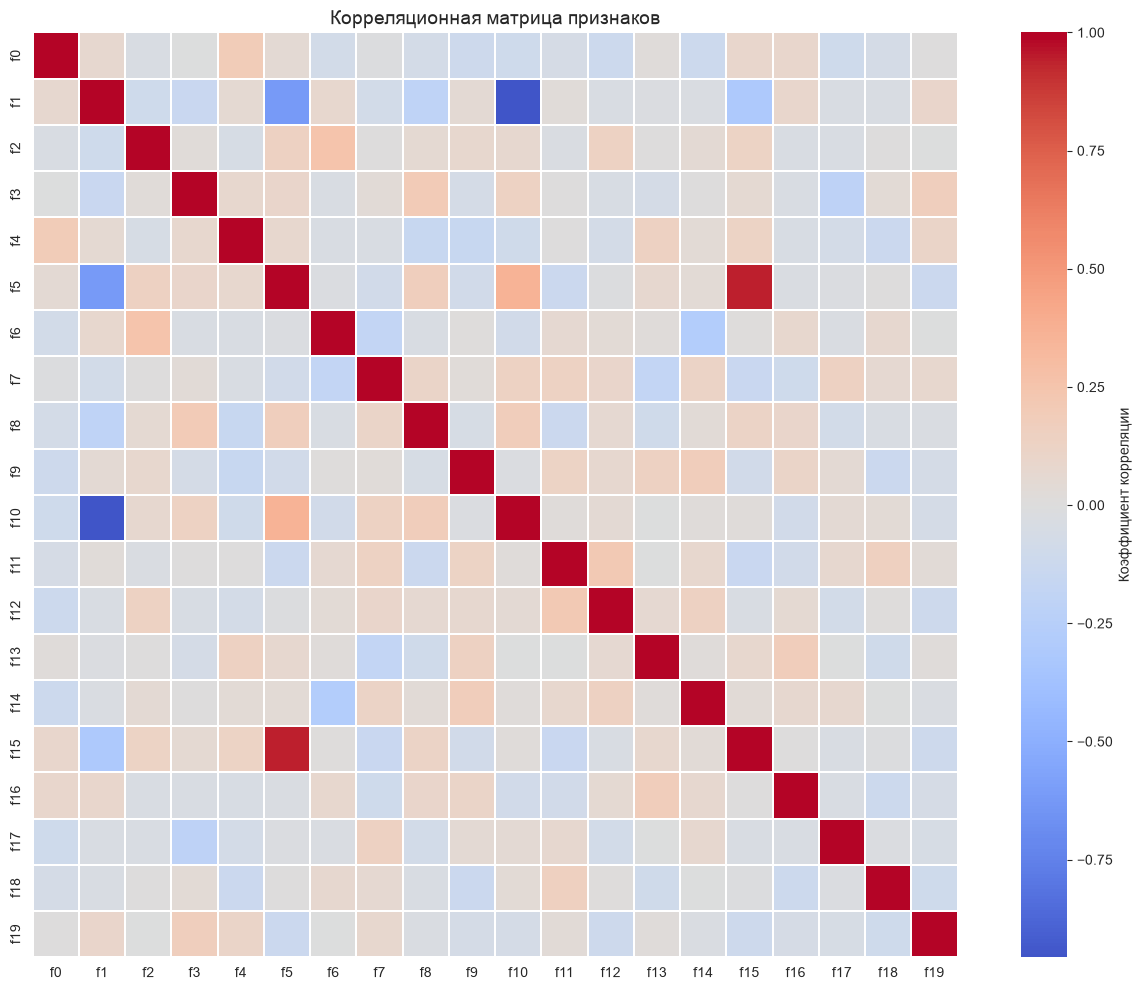

|Корреляция| признаков с таргетом (топ-10):
f10    0.865
f1     0.763
f15    0.202
f8     0.196
f4     0.172
f6     0.167
f7     0.147
f3     0.119
f5     0.108
f17    0.096
dtype: float64


In [4]:
corr_with_target = X.corrwith(pd.Series(y, name='target'))

corr_matrix = X.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True,
            linewidths=0.3, cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

print('|Корреляция| признаков с таргетом (топ-10):')
print(corr_with_target.abs().sort_values(ascending=False).head(10).round(3))

In [5]:
CORR_THRESHOLD = 0.1
corr_features = corr_with_target[corr_with_target.abs() > CORR_THRESHOLD].index.tolist()

print(f'Порог |corr| > {CORR_THRESHOLD}')
print(f'Отобрано признаков: {len(corr_features)}')
print('Признаки:', corr_features)

Порог |corr| > 0.1
Отобрано признаков: 9
Признаки: ['f1', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f10', 'f15']


### 3b. Отсечение низковариативных признаков (VarianceThreshold)

In [6]:
print('Статистика дисперсий признаков:')
print(X.var().describe().round(3))

VAR_THRESHOLD = 1.0
vt = VarianceThreshold(threshold=VAR_THRESHOLD).fit(X)
vt_features = X.columns[vt.get_support()].tolist()

print(f'Оставшиеся признаки при пороге {VAR_THRESHOLD}:', vt_features)

Статистика дисперсий признаков:
count    20.000
mean      1.082
std       0.280
min       0.747
25%       0.864
50%       0.984
75%       1.218
max       1.753
dtype: float64
Оставшиеся признаки при пороге 1.0: ['f1', 'f2', 'f5', 'f8', 'f10', 'f11', 'f13', 'f14', 'f17']


### 3c. Оценка моделей на отобранных признаках (повтор п. 2)

In [7]:
evaluate(X[corr_features], '3a. Корреляция с таргетом')
evaluate(X[vt_features],   '3b. VarianceThreshold');

3a. Корреляция с таргетом                  | признаков:  9 | accuracy = 0.9800
3b. VarianceThreshold                      | признаков:  9 | accuracy = 0.9700


## 4. Отбор на основе дисперсионного анализа (ANOVA, f_classif)

### 4a. SelectKBest(f_classif, k=5)

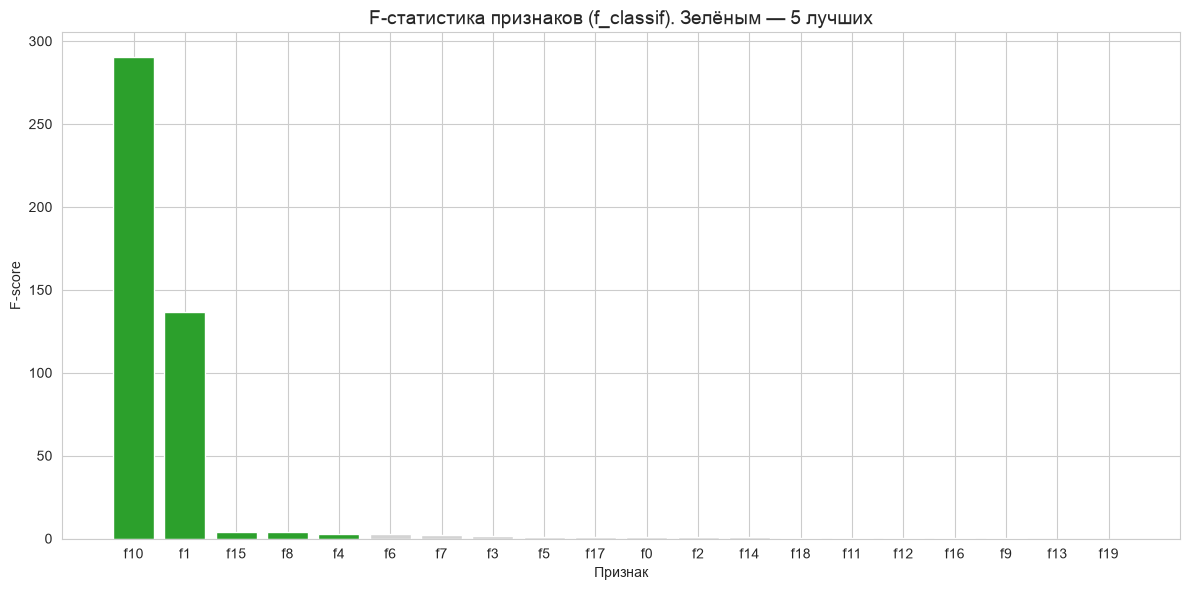

Отобранные 5 лучших признаков: ['f1', 'f4', 'f8', 'f10', 'f15']


In [8]:
skb = SelectKBest(score_func=f_classif, k=5).fit(X, y)
kbest_features = X.columns[skb.get_support()].tolist()

scores = pd.Series(skb.scores_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['tab:green' if f in kbest_features else 'lightgray' for f in scores.index]
plt.bar(scores.index, scores.values, color=colors, edgecolor='white')
plt.title('F-статистика признаков (f_classif). Зелёным — 5 лучших', fontsize=14)
plt.xlabel('Признак')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

print('Отобранные 5 лучших признаков:', kbest_features)

### 4b. Оценка модели (повтор п. 2)

In [9]:
evaluate(X[kbest_features], '4. SelectKBest(f_classif, k=5)');

4. SelectKBest(f_classif, k=5)             | признаков:  5 | accuracy = 0.9800


## 5. Отбор с использованием моделей (SelectFromModel)

### 5a. Логистическая регрессия с L1-регуляризацией

In [10]:
l1_logreg = LogisticRegression(
    penalty='l1', solver='liblinear', C=1.0, random_state=RANDOM_STATE
).fit(X, y)

sfm_l1 = SelectFromModel(l1_logreg, prefit=True)
l1_features = X.columns[sfm_l1.get_support()].tolist()

print('Ненулевые веса L1-модели:')
coefs = pd.Series(l1_logreg.coef_[0], index=X.columns)
print(coefs[coefs != 0].round(3).sort_values(key=abs, ascending=False))
print(f'\nОтобрано признаков: {len(l1_features)}')
print('Признаки:', l1_features)

Ненулевые веса L1-модели:
f10    4.400
f15   -1.699
f3     0.454
f18   -0.261
f14    0.063
f12   -0.039
f11   -0.022
f7    -0.015
f13    0.001
dtype: float64

Отобрано признаков: 9
Признаки: ['f3', 'f7', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f18']


### 5b. RandomForest и feature\_importances\_

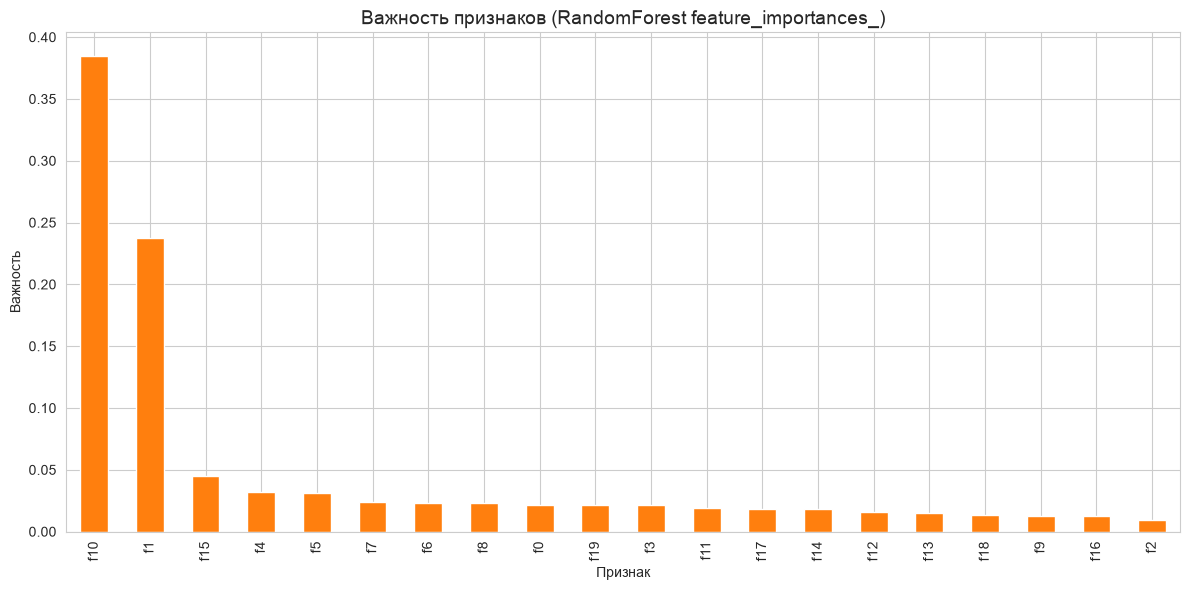

Отобрано признаков: 2
Признаки: ['f1', 'f10']


In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar', color='tab:orange', edgecolor='white')
plt.title('Важность признаков (RandomForest feature_importances_)', fontsize=14)
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

sfm_rf = SelectFromModel(rf, prefit=True)
rf_features = X.columns[sfm_rf.get_support()].tolist()
print('Отобрано признаков:', len(rf_features))
print('Признаки:', rf_features)

### 5c. Оценка моделей (повтор п. 2)

In [12]:
evaluate(X[l1_features], '5a. SelectFromModel (LogReg L1)')
evaluate(X[rf_features], '5b. SelectFromModel (RandomForest)');

5a. SelectFromModel (LogReg L1)            | признаков:  9 | accuracy = 0.9800
5b. SelectFromModel (RandomForest)         | признаков:  2 | accuracy = 0.9500


## 6. Перебор признаков (SequentialFeatureSelector)

### 6a. Последовательный жадный отбор

In [13]:
sfs = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000),
    n_features_to_select=5,
    direction='forward',
)
sfs.fit(X, y)
sfs_features = X.columns[sfs.get_support()].tolist()

print('Отобрано признаков:', len(sfs_features))
print('Признаки:', sfs_features)

Отобрано признаков: 5
Признаки: ['f0', 'f3', 'f5', 'f6', 'f10']


### 6b. Оценка модели (повтор п. 2)

In [14]:
evaluate(X[sfs_features], '6. SequentialFeatureSelector');

6. SequentialFeatureSelector               | признаков:  5 | accuracy = 1.0000


## 7. Выводы

### a) Сводная таблица результатов

In [15]:
summary = pd.DataFrame(results)
summary = summary.sort_values('средняя точность', ascending=False).reset_index(drop=True)
summary

,способ выбора признаков,количество признаков,средняя точность
0,6. SequentialFeatureSelector,5,1.00
1,3a. Корреляция с таргетом,9,0.98
2,Все признаки (baseline),20,0.98
3,5a. SelectFromModel (LogReg L1),9,0.98
4,"4. SelectKBest(f_classif, k=5)",5,0.98
5,3b. VarianceThreshold,9,0.97
6,5b. SelectFromModel (RandomForest),2,0.95


### b) Общие выводы

1. **Отбор признаков не ухудшил, а местами улучшил качество.** Из 20 исходных признаков
   информативны лишь несколько; остальные — шум. Убрав их, удалось сохранить точность
   baseline (~0.98) на **в 2–4 раза меньшем** числе признаков.

2. **Лучший метод — `SequentialFeatureSelector`** (accuracy до 1.00 на 5 признаках):
   он напрямую оптимизирует метрику и подбирает взаимно дополняющие признаки, но самый
   затратный по времени.

3. **`SelectKBest(f_classif)` — лучший баланс** качества, простоты и скорости:
   ~0.98 на 5 признаках практически мгновенно.

4. **Модельные методы** удобны, когда модель уже обучается: L1-регуляризация и
   `RandomForest.feature_importances_` дают компактные наборы. RandomForest выделил
   всего 2 главных признака (минимальная модель ценой небольшого падения точности).

5. **`VarianceThreshold`** — самый слабый содержательный фильтр: высокая дисперсия
   не означает связь с таргетом. Его основная польза — удаление констант и почти-констант,
   которых в этих данных нет.

**Итог.** Отбор признаков позволяет строить более простые, быстрые и устойчивые к
переобучению модели без потери качества. Для этой задачи оптимальны обёрточные
(`SequentialFeatureSelector`) и дисперсионные (`SelectKBest`) методы.